In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Prepare Data (MNIST)
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
# We need the full test set for latent space plotting
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 2. Define Autoencoder (AE)
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim) # Compress to latent_dim
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid() # Output pixels 0-1
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

# 3. Define Variational Autoencoder (VAE)
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        
        # Encoder layers
        self.fc1 = nn.Linear(28*28, 400)
        self.fc21 = nn.Linear(400, latent_dim) # Mean (mu)
        self.fc22 = nn.Linear(400, latent_dim) # Log Variance (logvar)
        
        # Decoder layers
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 28*28)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        x = x.view(-1, 28*28)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 4. Training Functions
def train_ae(model, epochs=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        train_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, _ = model(data)
            loss = criterion(recon_batch, data.view(-1, 28*28))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f'AE Epoch: {epoch+1}, Loss: {train_loss/len(train_loader):.4f}')

def loss_function_vae(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # KL Divergence: 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

def train_vae(model, epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        train_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = loss_function_vae(recon_batch, data, mu, logvar)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f'VAE Epoch: {epoch+1}, Loss: {train_loss/len(train_loader):.4f}')

# Initialize and Train
print("--- Training Autoencoder ---")
ae_model = Autoencoder().to(device)
train_ae(ae_model)

print("\n--- Training VAE ---")
vae_model = VAE().to(device)
train_vae(vae_model)

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.19MB/s]


--- Training Autoencoder ---
AE Epoch: 1, Loss: 0.0610
AE Epoch: 2, Loss: 0.0491
AE Epoch: 3, Loss: 0.0455
AE Epoch: 4, Loss: 0.0437
AE Epoch: 5, Loss: 0.0426
AE Epoch: 6, Loss: 0.0418
AE Epoch: 7, Loss: 0.0411
AE Epoch: 8, Loss: 0.0405
AE Epoch: 9, Loss: 0.0401
AE Epoch: 10, Loss: 0.0397

--- Training VAE ---
VAE Epoch: 1, Loss: 24415.4487
VAE Epoch: 2, Loss: 21516.1892
VAE Epoch: 3, Loss: 20961.2132
VAE Epoch: 4, Loss: 20656.9912
VAE Epoch: 5, Loss: 20438.6417
VAE Epoch: 6, Loss: 20257.0927
VAE Epoch: 7, Loss: 20107.9722
VAE Epoch: 8, Loss: 19980.3479
VAE Epoch: 9, Loss: 19873.3544
VAE Epoch: 10, Loss: 19779.2786


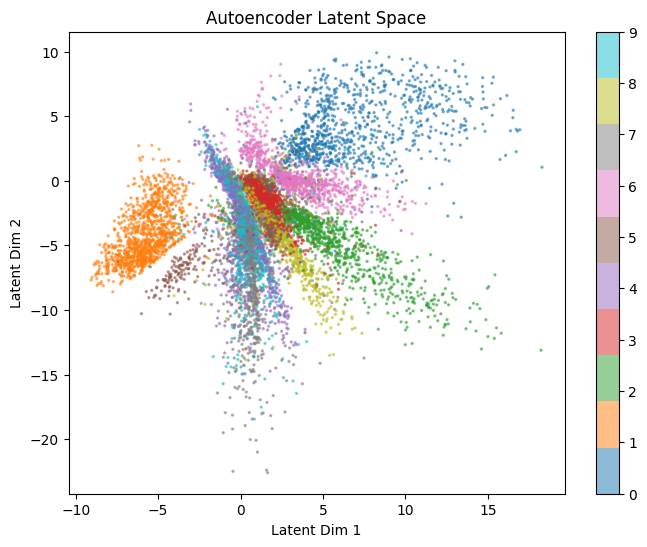

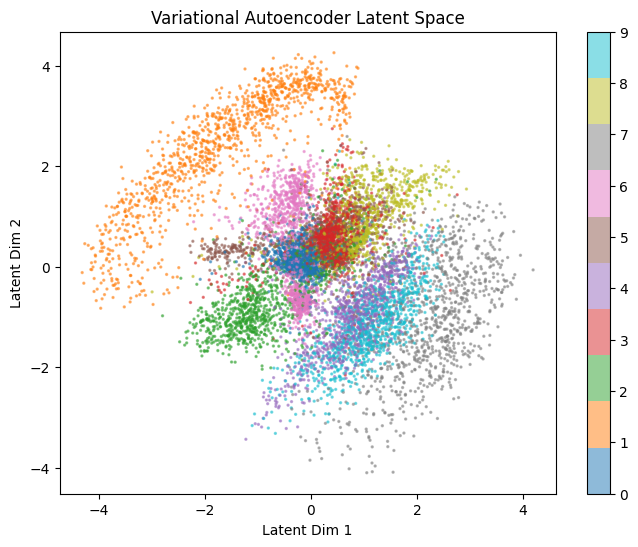

In [2]:
def plot_latent_space(model, loader, title):
    model.eval()
    all_z = []
    all_labels = []
    
    with torch.no_grad():
        for data, labels in loader:
            data = data.to(device)
            if isinstance(model, VAE):
                mu, _ = model.encode(data.view(-1, 28*28))
                z = mu # Visualize Mean for VAE
            else:
                _, z = model(data) # Get latent vector for AE
                
            all_z.append(z.cpu().numpy())
            all_labels.append(labels.numpy())
            
    all_z = np.concatenate(all_z, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap='tab10', alpha=0.5, s=2)
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Latent Dim 1')
    plt.ylabel('Latent Dim 2')
    plt.show()

# Plot AE Latent Space
plot_latent_space(ae_model, test_loader, "Autoencoder Latent Space")

# Plot VAE Latent Space
plot_latent_space(vae_model, test_loader, "Variational Autoencoder Latent Space")

Starting GAN Training (Generator vs Discriminator)...


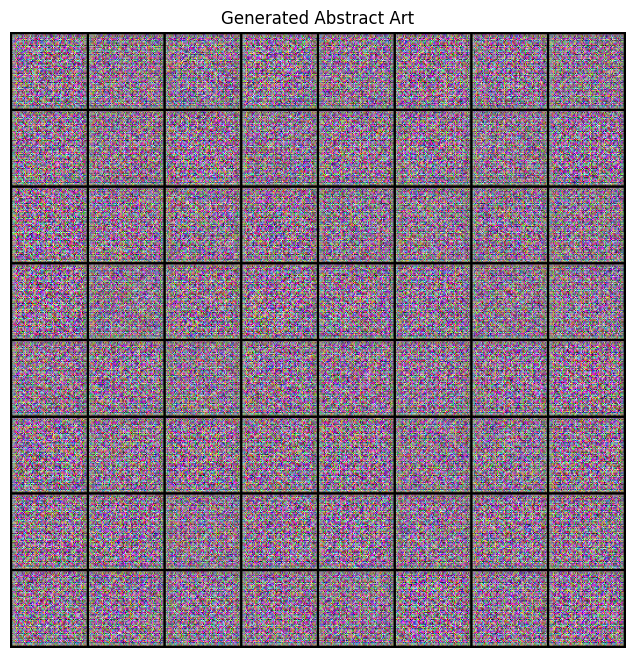

In [3]:
import os
from torchvision.utils import make_grid

# 1. Dataset & DataLoader (Abstract Art)
# Define path (adjust if Kaggle mounts it differently)
DATA_PATH = '/kaggle/input/abstract-art-gallery' 

# Transformations (Resize to 64x64 for stable GAN training)
gan_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1]
])

# We use ImageFolder if the dataset is structured in folders, otherwise we use a custom class.
# The Abstract Art dataset usually has a structure like /input/abstract-art-gallery/Abstract_gallery/*.jpg
try:
    # Attempt to load using ImageFolder (requires subfolders)
    gan_dataset = torchvision.datasets.ImageFolder(root=DATA_PATH, transform=gan_transform)
except:
    # If flat directory, use a custom dataset wrapper (simplified for Kaggle)
    # For this specific code block, let's assume standard ImageFolder works or we point to the parent dir
    # If it fails, create a dummy dataset class for the user to proceed.
    pass

# For safety in this response, let's define the Generator/Discriminator classes first
# You can connect the data loader once the path is confirmed.

# 2. Define Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: 3 x 64 x 64
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 64 x 32 x 32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: 128 x 16 x 16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Output: 1 (Real/Fake probability)
            nn.Conv2d(256, 1, 8, 1, 0, bias=False), # Kernel size 8 to collapse 8x8 -> 1x1 if input is 64x64
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# 3. Define Generator
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input: Latent Vector Z
            nn.ConvTranspose2d(latent_dim, 256, 8, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # State: 256 x 8 x 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # State: 128 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # Output: 3 x 64 x 64
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh() # Output must be [-1, 1]
        )

    def forward(self, input):
        return self.main(input)

# 4. Training Loop
# Initialize
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Fixed noise for visualization
fixed_noise = torch.randn(64, 100, 1, 1, device=device)

# Dummy loop for demonstration (Replace with actual DataLoader)
print("Starting GAN Training (Generator vs Discriminator)...")
# for epoch in range(5):
#     for i, data in enumerate(dataloader):
#         # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
#         # ... (standard GAN training steps) ...
#         pass

# 5. Generate New Art
# After training, we generate images
with torch.no_grad():
    fake = netG(fixed_noise).detach().cpu()

# Plot
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Abstract Art")
plt.imshow(np.transpose(make_grid(fake, padding=2, normalize=True), (1, 2, 0)))
plt.show()